In [1]:
# ============================================================
# IMPORTAR LIBRERIAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# PASO 1: CARGAR DATOS
# ============================================================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/sis420/Laboratorios/Lab 6/mening missing 12.csv')

print(f'Dimensiones: {df.shape}')
target_col = 'Diagnosis'
print(f'Target configurado: {target_col}')
df.head()

Dimensiones: (1200, 14)
Target configurado: Diagnosis


,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,1,101.0,Female,8624.0,16.0,83.0,No,Viral,Recovered,15.0,7269.0,160949.0,71.0,Moderate Risk
1,2,78.0,Male,22623.0,200.0,41.0,No,Unknown,Recovered,18.0,6532.0,371741.0,41.0,High Risk
2,3,8.0,Female,12908.0,39.0,3.0,No,Unknown,Recovered,16.0,7417.0,180403.0,22.0,Moderate Risk
3,4,104.0,Female,15072.0,58.0,36.0,Yes,Bacterial,Recovered,7.0,13792.0,132254.0,48.0,Moderate Risk
4,5,38.0,Female,18623.0,152.0,34.0,Yes,Bacterial,Recovered,5.0,17054.0,134941.0,28.0,High Risk


In [5]:
# ============================================================
# PASO 2: ELIMINAR DUPLICADOS Y NULOS
# ============================================================
# Duplicados
duplicados = df.duplicated().sum()
if duplicados > 0:
    df.drop_duplicates(inplace=True)
    print(f'Eliminados {duplicados} duplicados.')

# Nulos
nulos_totales = df.isnull().sum().sum()
if nulos_totales > 0:
    df.dropna(inplace=True)
    print(f'Eliminados valores nulos. Dimensiones actuales: {df.shape}')

Eliminados valores nulos. Dimensiones actuales: (1074, 14)


/tmp/ipykernel_4579/162088342.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target_col, data=df, palette='viridis')


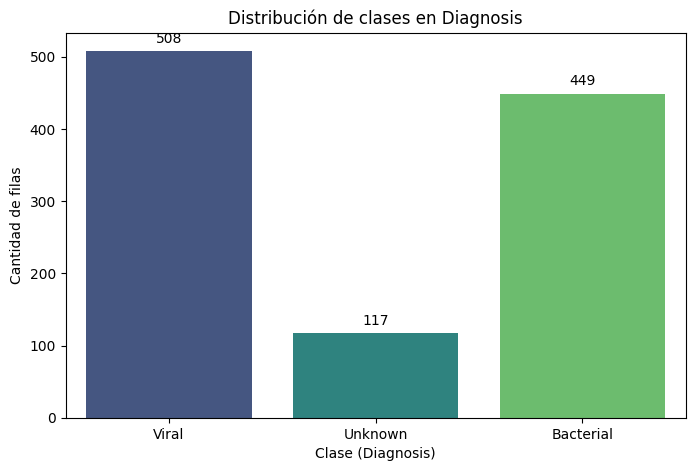

In [6]:
# ============================================================
# PASO 3: GRAFICAR LA CANTIDAD DE FILAS POR CLASE
# ============================================================
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=target_col, data=df, palette='viridis')
plt.title(f'Distribución de clases en {target_col}')
plt.xlabel('Clase (Diagnosis)')
plt.ylabel('Cantidad de filas')

# Añadir el número de la cantidad sobre cada barra
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')
plt.show()

In [7]:
# ============================================================
# PASO 4: CONVERTIR COLUMNAS A NÚMEROS (GET DUMMIES)
# ============================================================
# La variable target a números primero con LabelEncoder para clasificación
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_clases_originales = df[target_col].unique()

df[target_col] = le.fit_transform(df[target_col])
print("Clases codificadas:")
for ori, cod in zip(le.classes_, range(len(le.classes_))):
    print(f"  {ori} => {cod}")

# get_dummies en las variables dependientes (Features)
X_features = df.drop(target_col, axis=1)
X_features = pd.get_dummies(X_features, drop_first=True)

df_encoded = pd.concat([X_features, df[target_col]], axis=1)

print("\nDimensiones tras get_dummies:", df_encoded.shape)
df_encoded.head()

Clases codificadas:
  Bacterial => 0
  Unknown => 1
  Viral => 2

Dimensiones tras get_dummies: (1074, 15)


,Patient_ID,Age,WBC_Count,Protein_Level,Glucose_Level,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Gender_Male,Pathogen_Present_Yes,Outcome_Recovered,Risk_Level_Low Risk,Risk_Level_Moderate Risk,Diagnosis
0,1,101.0,8624.0,16.0,83.0,15.0,7269.0,160949.0,71.0,False,False,True,False,True,2
1,2,78.0,22623.0,200.0,41.0,18.0,6532.0,371741.0,41.0,True,False,True,False,False,1
2,3,8.0,12908.0,39.0,3.0,16.0,7417.0,180403.0,22.0,False,False,True,False,True,1
3,4,104.0,15072.0,58.0,36.0,7.0,13792.0,132254.0,48.0,False,True,True,False,True,0
4,5,38.0,18623.0,152.0,34.0,5.0,17054.0,134941.0,28.0,False,True,True,False,False,0


In [8]:
# ============================================================
# PASO 5: X e Y y BALANCEO DE CLASES (SMOTE)
# ============================================================
# Preparar X y
X_arr = X_features.values.astype(np.float32)
y_arr = df_encoded[target_col].values.astype(np.int64)

# SMOTE Multiclase
print(f'ANTES del balanceo:')
unique, counts = np.unique(y_arr, return_counts=True)
for u, c in dict(zip(unique, counts)).items():
    print(f'  Clase {u} ({le.classes_[u]}): {c}')

# Usar SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_arr, y_arr)

print(f'\nDESPUÉS del balanceo:')
unique_res, counts_res = np.unique(y_res, return_counts=True)
for u, c in dict(zip(unique_res, counts_res)).items():
    print(f'  Clase {u} ({le.classes_[u]}): {c}')

ANTES del balanceo:
  Clase 0 (Bacterial): 449
  Clase 1 (Unknown): 117
  Clase 2 (Viral): 508

DESPUÉS del balanceo:
  Clase 0 (Bacterial): 508
  Clase 1 (Unknown): 508
  Clase 2 (Viral): 508


In [9]:
# ============================================================
# PASO 6: SEPARAR TRAIN Y TEST
# ============================================================
# Se secciona estratificadamente 80% Entrenamiento - 20% Prueba
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.20, random_state=42, stratify=y_res
)

print(f"Set de Entrenamiento (X_train): {X_train_raw.shape}")
print(f"Set de Prueba (X_test): {X_test_raw.shape}")

Set de Entrenamiento (X_train): (1219, 14)
Set de Prueba (X_test): (305, 14)


In [10]:
# ============================================================
# PASO 7: NORMALIZACIÓN
# ============================================================
def normalizar(data, mu=None, sigma=None):
    if mu is None:
        mu = np.mean(data, axis=0)
        sigma = np.std(data, axis=0)
        sigma[sigma == 0] = 1 # Evitar divisiones por cero
    return (data - mu) / sigma, mu, sigma

# Escalar Train y Test
X_train, mu, sigma = normalizar(X_train_raw)
X_test, _, _ = normalizar(X_test_raw, mu, sigma)

print("Datos normalizados para procesar modelos:")
print(f'Train -> X: {X_train.shape}, y: {y_train.shape}')
print(f'Test  -> X: {X_test.shape}, y: {y_test.shape}')

Datos normalizados para procesar modelos:
Train -> X: (1219, 14), y: (1219,)
Test  -> X: (305, 14), y: (305,)


In [11]:
# ============================================================
# PASO 8: MODELO - CLASIFICACIÓN LOGÍSTICA MULTICLASE (SOFTMAX)
# ============================================================
# Adaptación de Regresión Logística y Perceptrón Multiclase
class LogisticRegressionMulticlass():
  def __init__(self, size, n_classes):
    np.random.seed(42)
    self.w = np.random.normal(loc=0.0,
          scale=np.sqrt(2/(size+1)),
          size=(size, n_classes))
    self.ws = []

  def __softmax(self, z):
      exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
      return exp_z / np.sum(exp_z, axis=1, keepdims=True)

  def __cross_entropy_loss(self, y_onehot, y_hat):
      m = y_onehot.shape[0]
      return -np.sum(y_onehot * np.log(y_hat + 1e-15)) / m

  def __call__(self, w, x):
    return self.__softmax(np.dot(x, w))

  def fit(self, x, y, epochs, lr, n_classes, verbose=True):
    x = np.c_[np.ones(len(x)), x]
    # One-hot encoding manual para el batch gradient descent (etiquetas -> forma OHE)
    y_ohe = np.zeros((len(y), n_classes))
    y_ohe[np.arange(len(y)), y] = 1

    for epoch in range(1, epochs+1):
        # Forward pass (Batch Gradient Descent)
        y_hat = self(self.w, x)

        # Loss function (Cross Entropy)
        l = self.__cross_entropy_loss(y_ohe, y_hat)

        # Backward pass / Derivadas locales
        dldz = (y_hat - y_ohe)
        dldw = np.dot(x.T, dldz) / len(y)

        # Update pesos
        self.w = self.w - lr * dldw
        self.ws.append(self.w.copy())

        if verbose and epoch % (epochs//10) == 0:
            print(f"Epoch {epoch}/{epochs} Loss {l:.5f}")

In [12]:
# ============================================================
# PASO 9: ENTRENAMIENTO Y PREDICCIÓN MULTICLASE
# ============================================================
n_clases = len(np.unique(y_test))
features_size = X_train.shape[1] + 1

print(f"Iniciando entrenamiento Perceptrón Multiclase ({n_clases} clases)")
perceptron_multi = LogisticRegressionMulticlass(size=features_size, n_classes=n_clases)

epochs, lr = 1000, 0.05
perceptron_multi.fit(X_train, y_train, epochs, lr, n_classes=n_clases, verbose=True)

# Evaluación: Funciones
def predict(model, x):
    w = model.ws[-1]
    x_b = np.c_[np.ones(len(x)), x]
    y_prob = model(w, x_b)
    # Devuelve la clase con mayor probabilidad (argmax)
    return np.argmax(y_prob, axis=1), y_prob

print("\nEntrenamiento Completado. Realizando predicciones sobre datos de test.")
y_pred, y_pred_prob = predict(perceptron_multi, X_test)

Iniciando entrenamiento Perceptrón Multiclase (3 clases)
Epoch 100/1000 Loss 0.59919
Epoch 200/1000 Loss 0.56166
Epoch 300/1000 Loss 0.55076
Epoch 400/1000 Loss 0.54548
Epoch 500/1000 Loss 0.54232
Epoch 600/1000 Loss 0.54025
Epoch 700/1000 Loss 0.53885
Epoch 800/1000 Loss 0.53787
Epoch 900/1000 Loss 0.53718
Epoch 1000/1000 Loss 0.53669

Entrenamiento Completado. Realizando predicciones sobre datos de test.


In [13]:
# ============================================================
# PASO 10: DIAGNÓSTICO DE PRECISIÓN BÁSICA (MULTICLASE)
# ============================================================
# Metrics para el uso global de la clasificación multiclase (macro/micro params)
acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"============================================================")
print(f"MÉTRICAS DEL MODELO MULTICLASE (Macro Avg):")
print(f"============================================================")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec_macro:.4f}")
print(f"Recall   : {rec_macro:.4f}")
print(f"F1-Score : {f1_macro:.4f}")
print(f"============================================================")

MÉTRICAS DEL MODELO MULTICLASE (Macro Avg):
Accuracy : 0.7705
Precision: 0.7714
Recall   : 0.7706
F1-Score : 0.7709


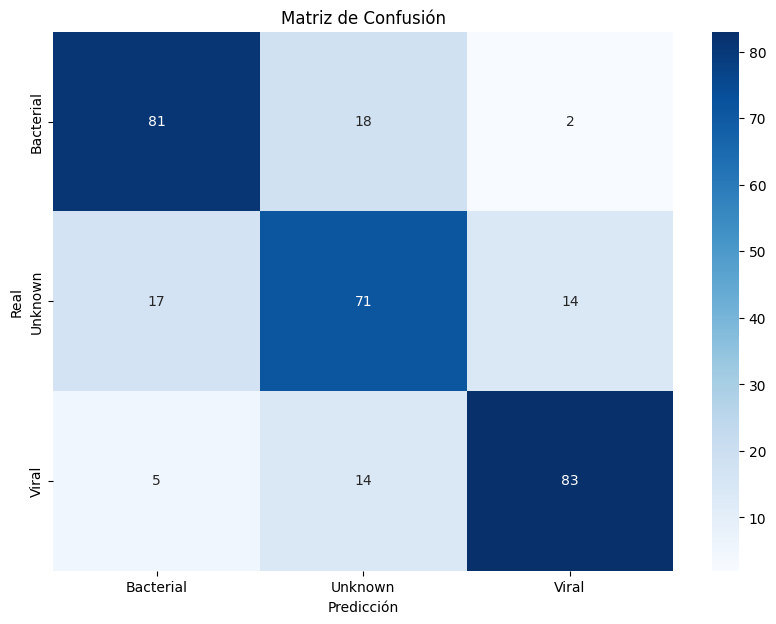


Área Bajo la Curva (AUC OVR ROC): 0.9124


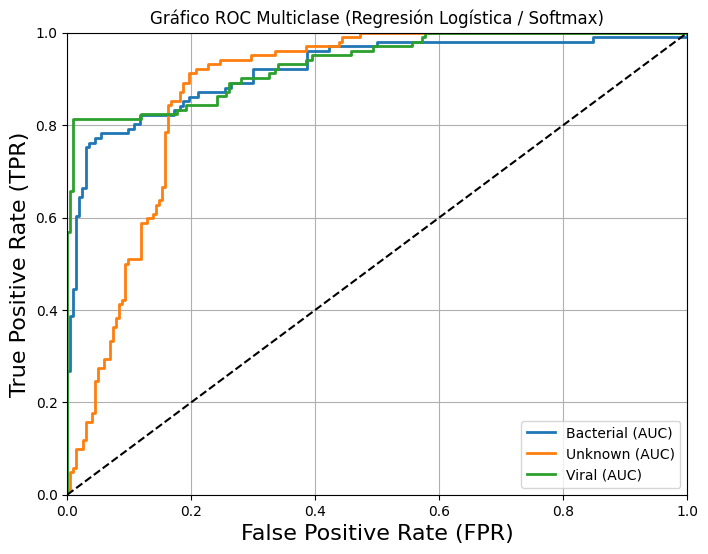

In [14]:
# ============================================================
# PASO 11: MATRIZ DE CONFUSIÓN MULTICLASE
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_ )
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# ============================================================
# PASO 12: CURVAS ROC Y AUC SCORE MULTICLASE (ONE-VS-REST)
# ============================================================
# Convertir y_test real a OHE OneHot por ROC AUC multiclass
y_test_bin = label_binarize(y_test, classes=[*range(n_clases)])

roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

print(f'\nÁrea Bajo la Curva (AUC OVR ROC): {roc_auc:.4f}')

# Curva individual
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'purple', 'orange']

for i in range(n_clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    label_class = le.classes_[i] if i < len(le.classes_) else f"Class {i}"
    plt.plot(fpr, tpr, linewidth=2, label=f'{label_class} (AUC)')
plt.plot([0, 1], [0, 1], 'k--')
plt.axis([0, 1, 0, 1])
plt.xlabel('False Positive Rate (FPR)', fontsize=16)
plt.ylabel('True Positive Rate (TPR)', fontsize=16)
plt.grid(True)
plt.title(f'Gráfico ROC Multiclase (Regresión Logística / Softmax)')
plt.legend(loc='lower right')
plt.show()